# Предобработка данных

## Цель работы

Познакомиться с основными задачами и приемами предварительного анализа и обработки данных для целей машинного обучения.

## 1. Подготовка и загрузка данных

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
training_set = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.5%20EDA/data/titanic.csv")
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Численная статистика:

In [5]:
training_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Статистика по категориальным признакам:

In [6]:
training_set.describe(include=['O'])

C:\Users\w1nore\AppData\Local\Temp\ipykernel_16488\2198228790.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  training_set.describe(include=['O'])


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 2. Визуализация распределения признаков

In [7]:
def custom_hist(data, title, xlabel, ylabel='Количество', bins=None):
    figsize = (20, 6)
    plt.figure(figsize=figsize)
    plt.grid(True)
    plt.title(title)
    plt.hist(data, data.max().astype(int) if bins is None else bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

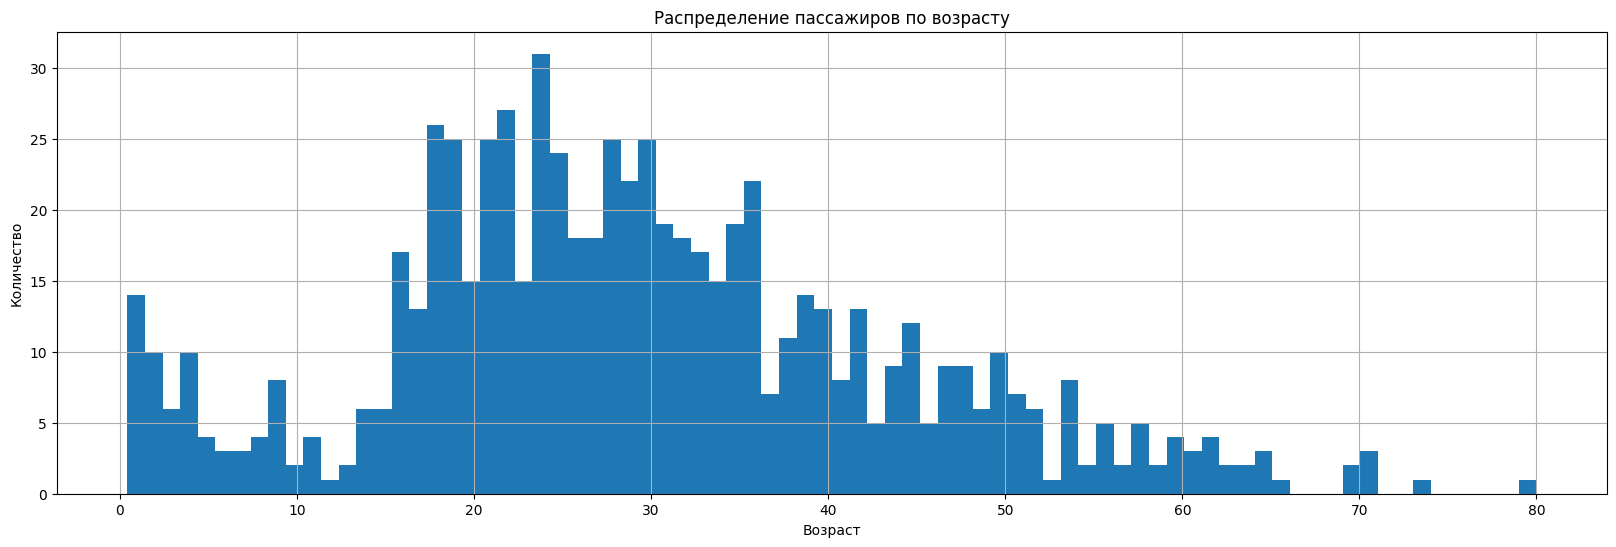

In [8]:
custom_hist(training_set['Age'], 'Распределение пассажиров по возрасту', 'Возраст')

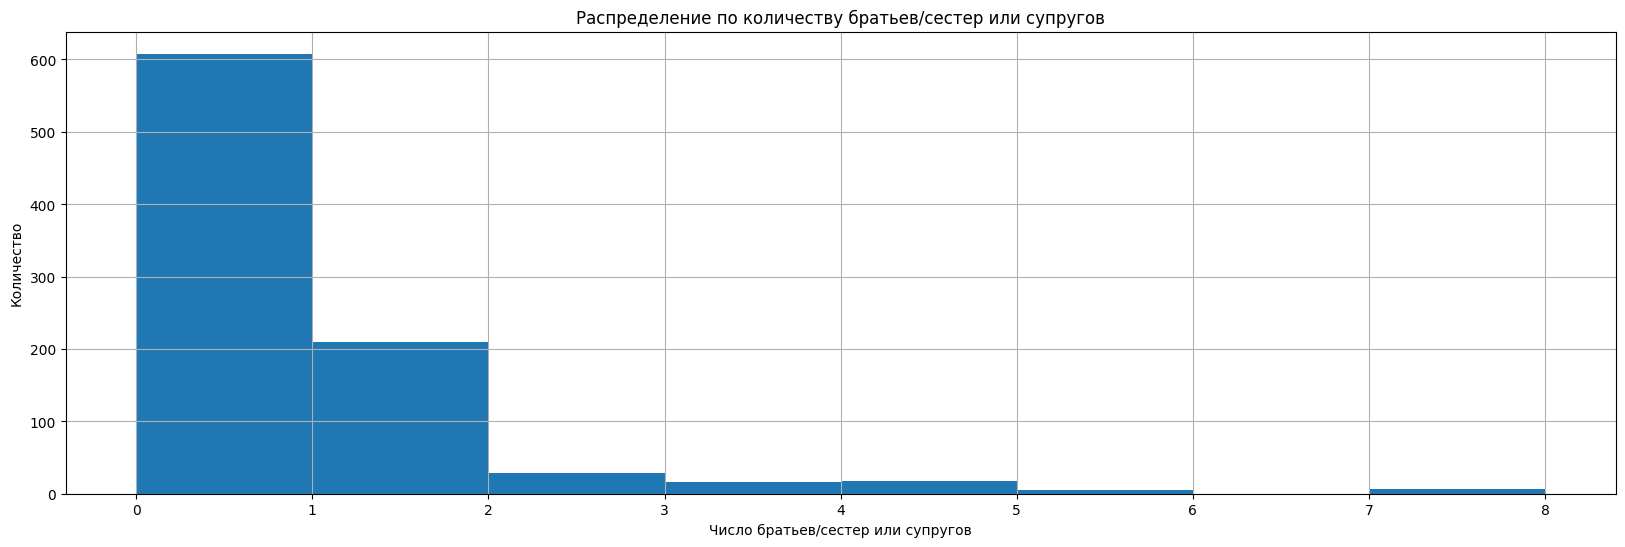

In [9]:
custom_hist(training_set['SibSp'], 'Распределение по количеству братьев/сестер или супругов', 
            'Число братьев/сестер или супругов')

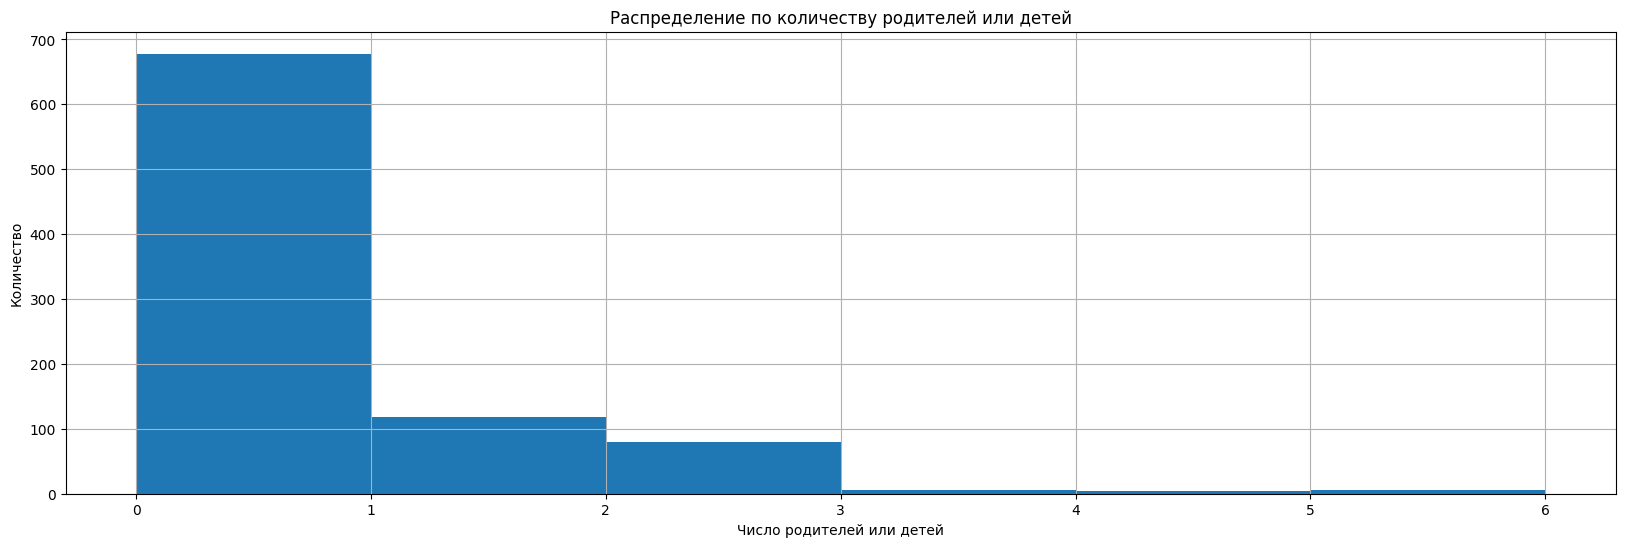

In [10]:
custom_hist(training_set['Parch'], 'Распределение по количеству родителей или детей', 
            'Число родителей или детей')

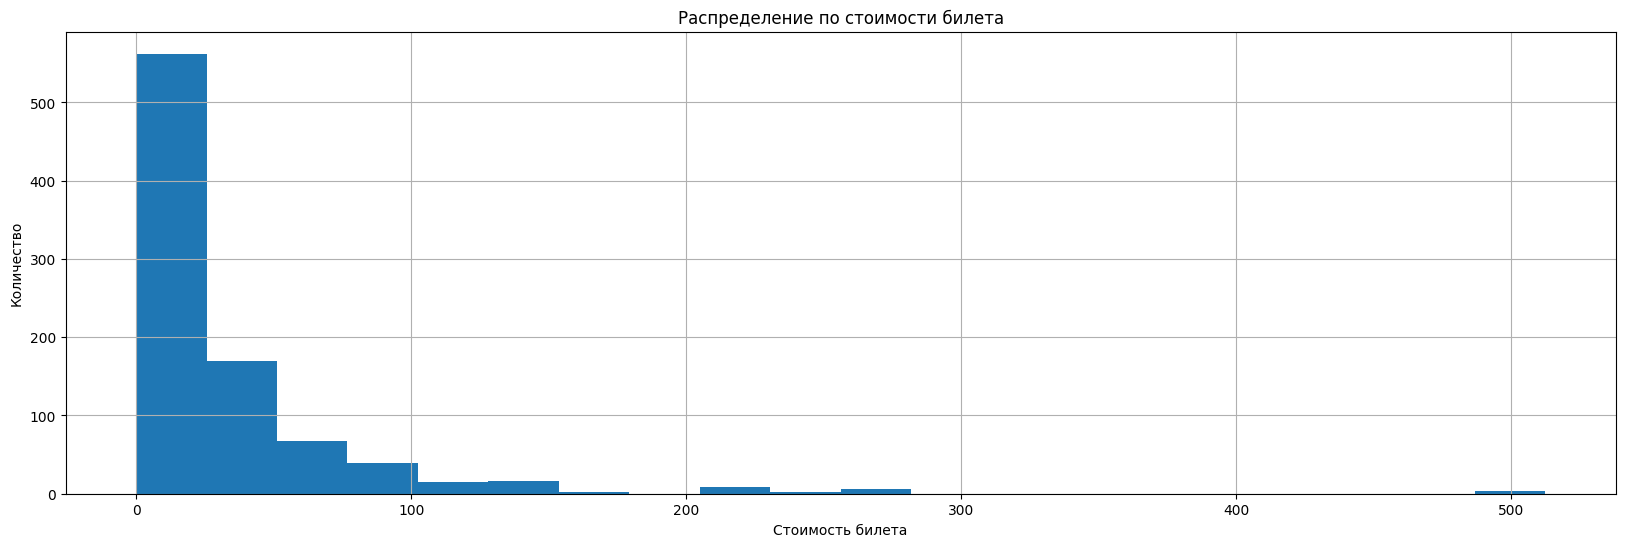

In [11]:
custom_hist(training_set['Fare'], 'Распределение по стоимости билета', 
            'Стоимость билета', bins=20)

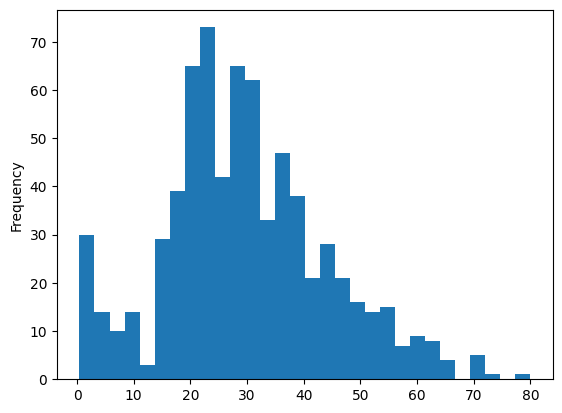

In [12]:
training_set['Age'].plot.hist(bins=30)
plt.show()

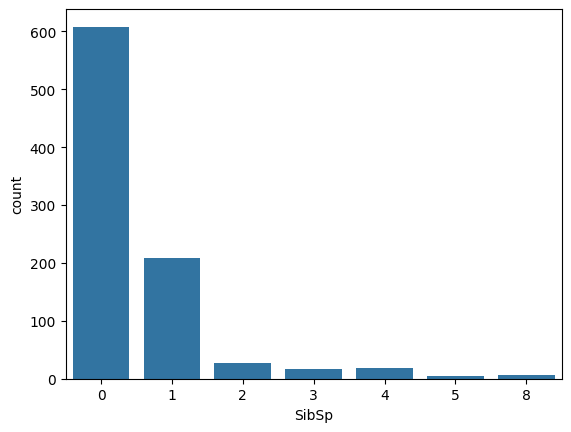

In [13]:
sns.countplot(x='SibSp', data=training_set)
plt.show()

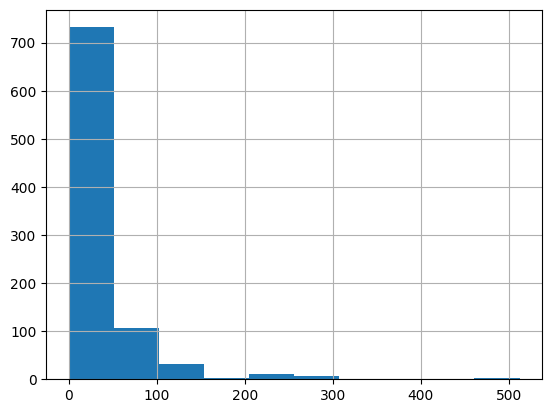

In [14]:
training_set['Fare'].hist()
plt.show()

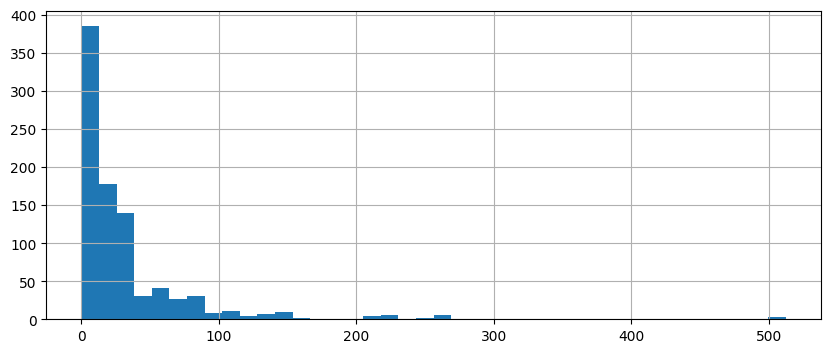

In [15]:
training_set['Fare'].hist(bins=40, figsize=(10, 4))
plt.show()

## 3. Совместное распределение признаков с целевой переменной

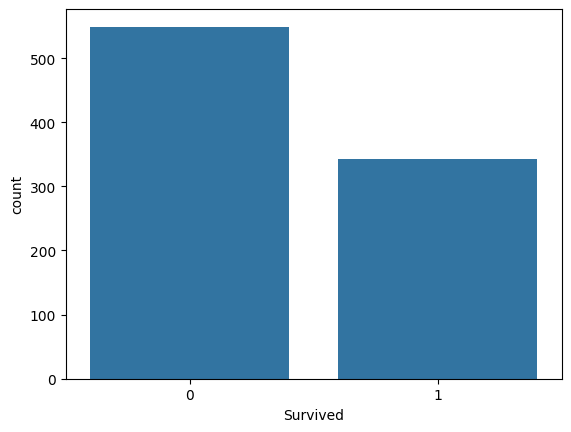

In [16]:
sns.countplot(x='Survived', data=training_set)
plt.show()

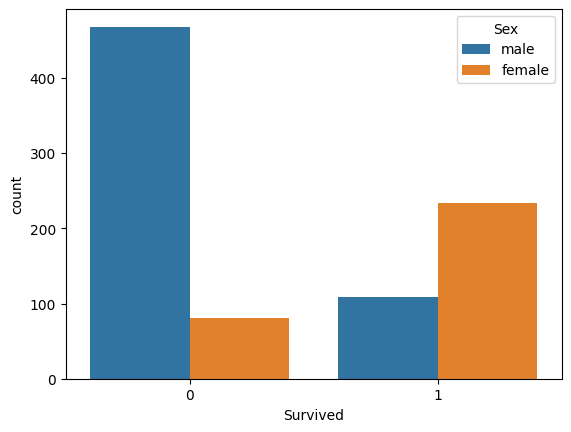

In [17]:
sns.countplot(x='Survived', data=training_set, hue='Sex')
plt.show()

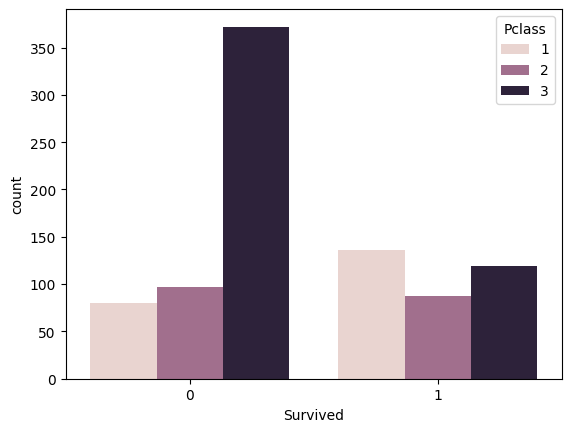

In [18]:
sns.countplot(x='Survived', data=training_set, hue='Pclass')
plt.show()

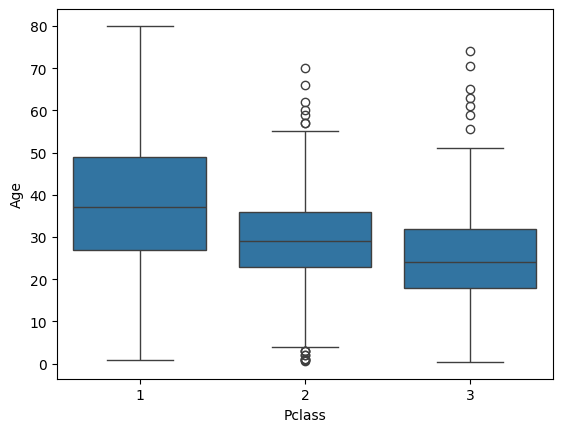

In [19]:
sns.boxplot(x='Pclass', y='Age', data=training_set)
plt.show()

Доля выживших для каждого значения признаков:

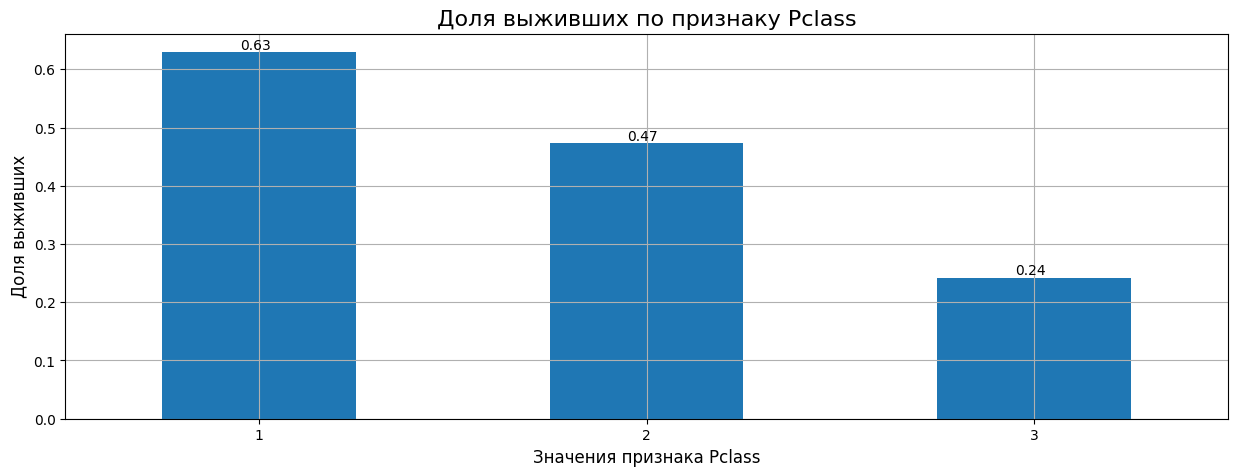

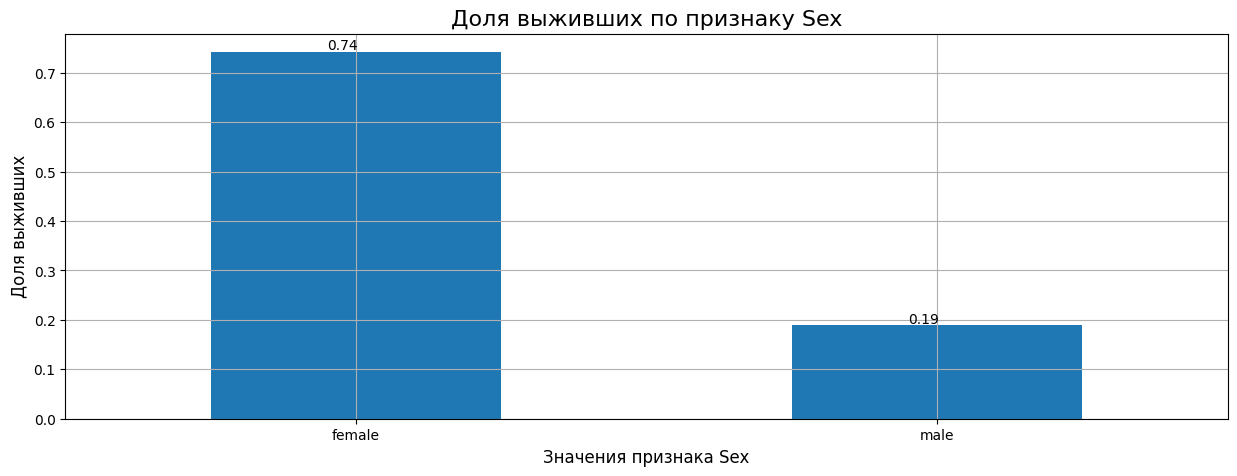

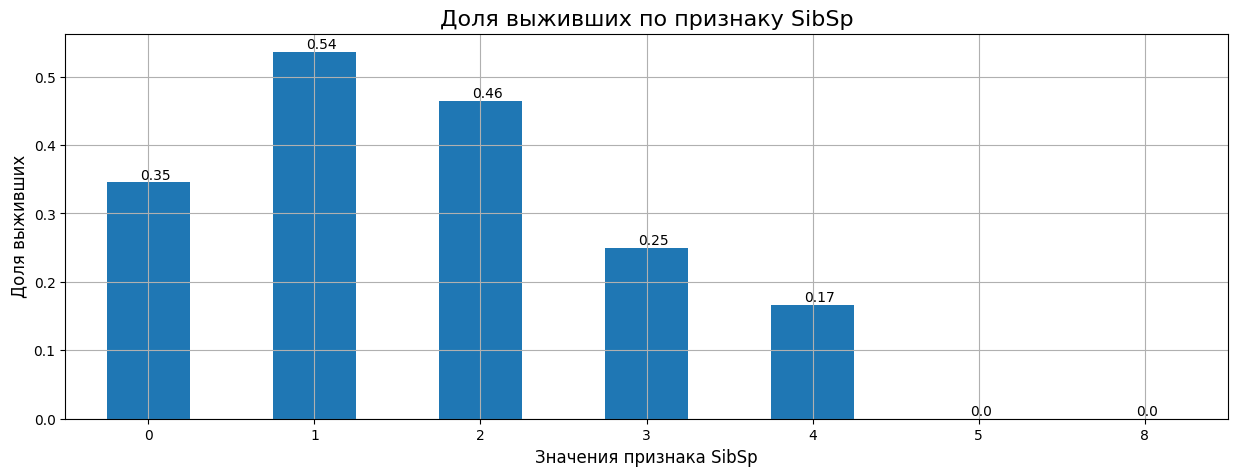

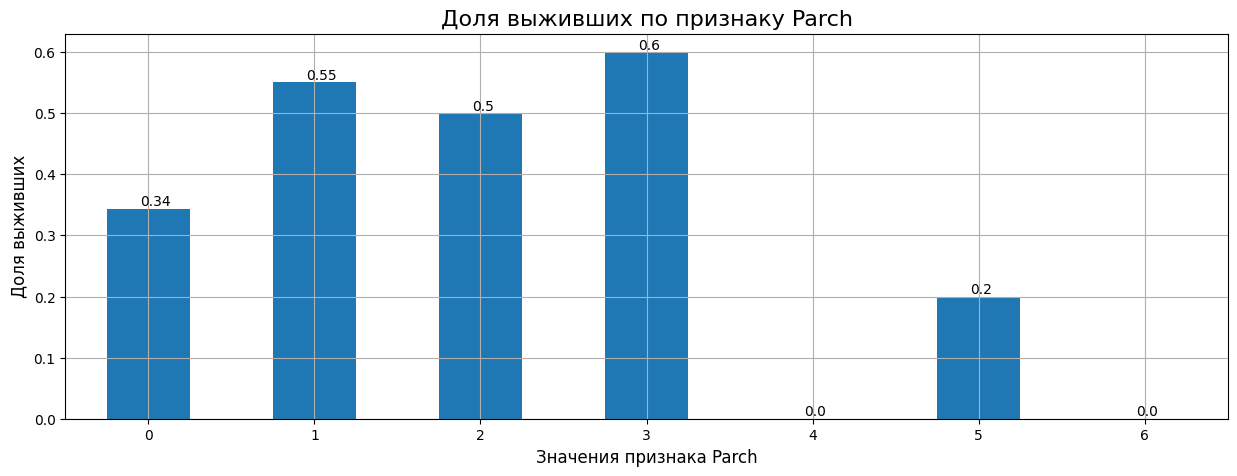

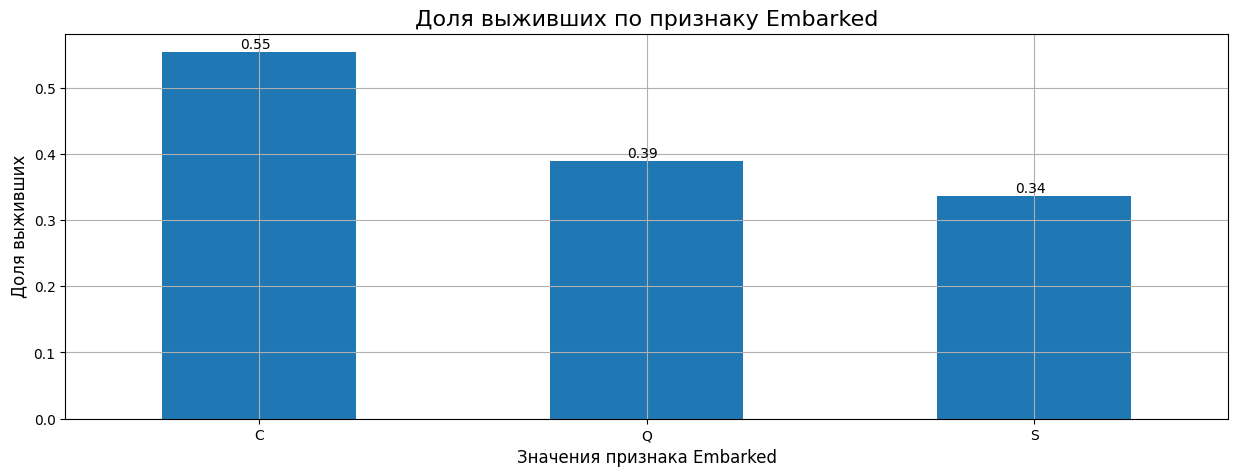

In [20]:
columns_to_look = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

for column in columns_to_look:
    pivot = training_set.pivot_table(index=column, values='Survived', aggfunc='mean')
    
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.set_title(f'Доля выживших по признаку {column}', fontdict={'size': 16})
    ax.set_ylabel('Доля выживших', fontdict={'size': 12})
    
    for cnt in range(pivot.shape[0]):
        value = pivot.iloc[cnt].values[0]
        ax.text(cnt - .05, value + .005, round(value, 2))
        
    pivot.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax)
    ax.set_xlabel(f'Значения признака {column}', fontdict={'size': 12})
    plt.show()

## 4. Исследование пропущенных значений

In [21]:
training_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [22]:
training_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

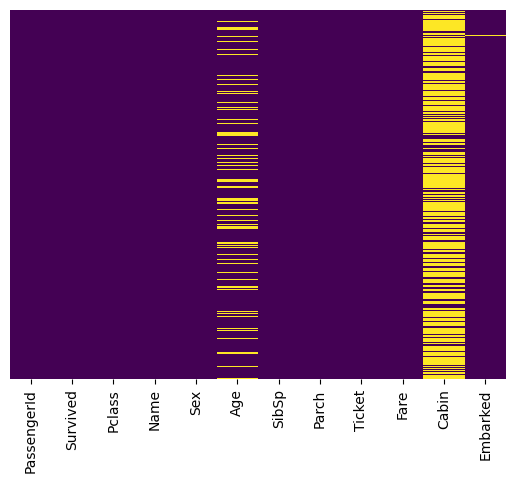

In [23]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

Удалим столбец Cabin (слишком много пропусков):

In [24]:
training_set.drop('Cabin', axis=1, inplace=True)

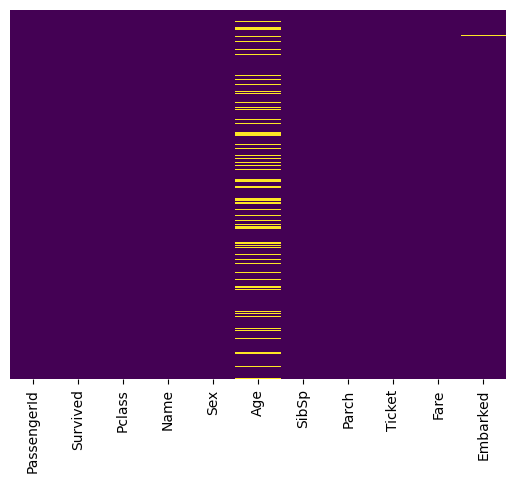

In [25]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

Удалим оставшиеся строки с пропущенными значениями:

In [26]:
training_set.dropna(inplace=True)
training_set.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 5. Преобразование категориальных признаков

### Label Encoding для Sex:

In [27]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
cat_enc_le = le.fit_transform(training_set['Sex'])
print('До:', training_set['Sex'].unique())
print('После:', np.unique(cat_enc_le))
print('Обратное преобразование:', le.inverse_transform([0, 1]))

До: <StringArray>
['male', 'female']
Length: 2, dtype: str
После: [0 1]
Обратное преобразование: ['female' 'male']


### OneHot Encoding для Embarked:

In [28]:
ohe = OneHotEncoder(sparse_output=False)
cat_enc_ohe = ohe.fit_transform(training_set[['Embarked']])
cat_enc_ohe

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]], shape=(712, 3))

In [29]:
training_set.shape

(712, 11)